In [17]:
## Import Libraries & Load Raw Data

import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})

DATA_DIR = "/Users/jemwagas/Week-2-Homework"  

customers    = pd.read_csv(os.path.join(DATA_DIR, "customers_data.csv"))
products     = pd.read_csv(os.path.join(DATA_DIR, "products_data.csv"))
transactions = pd.read_csv(os.path.join(DATA_DIR, "transactions_data.csv"))

print("Raw shapes:")
print(f"  customers    : {customers.shape}")
print(f"  products     : {products.shape}")
print(f"  transactions : {transactions.shape}")

Raw shapes:
  customers    : (100, 4)
  products     : (20, 3)
  transactions : (10000, 8)


In [19]:
## Customers: Drop Rows with Missing Company ID

cust = customers.drop_duplicates()

# Report before state
n_null_id = cust["Company_ID"].isna().sum()
print(f"Rows with null Company_ID (to be dropped): {n_null_id}")
print(f"Shape before: {cust.shape}")

cust = cust.dropna(subset=["Company_ID"])
cust["Company_ID"] = cust["Company_ID"].astype(int)

print(f"Shape after : {cust.shape}")
display(cust.head(3))

Rows with null Company_ID (to be dropped): 10
Shape before: (100, 4)
Shape after : (90, 4)


,Company_ID,Company_Name,Company_Profit,Address
0,1,Tech Enterprises 1,80701.0,"EDSA, Barangay 606, Pasig, Philippines"
1,2,Global Partners 2,80511.0,"Commonwealth Ave, Barangay 789, Taguig, Philip..."
2,3,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines"


In [23]:
## Customers: Fix Extra Whitespace in Company Names

before = cust[cust["Company_Name"].str.contains(r"  ", na=False)].shape[0]
print(f"Company names with extra whitespace (before): {before}")

cust["Company_Name"] = (cust["Company_Name"]
                            .str.replace(r"\s+", " ", regex=True)
                            .str.strip())

after = cust[cust["Company_Name"].str.contains(r"  ", na=False)].shape[0]
print(f"Company names with extra whitespace (after) : {after}")

# Show a before/after sample
sample_before = customers[customers["Company_Name"].str.contains(r"  ", na=False)]["Company_Name"].head(4).tolist()
sample_after  = cust[cust["Company_ID"].isin(
    customers[customers["Company_Name"].str.contains(r"  ", na=False)]["Company_ID"].dropna().astype(int).head(4)
)]["Company_Name"].tolist()

print("Before → After samples:")
for b, a in zip(sample_before, sample_after):
    print(f"  '{b}' → '{a}'")

Company names with extra whitespace (before): 26
Company names with extra whitespace (after) : 0
Before → After samples:
  'Tech  Enterprises  1' → 'Tech Enterprises 1'
  'Global  Partners  2' → 'Global Partners 2'
  'Elite  Ventures  5' → 'Elite Ventures 5'
  'Quantum  Enterprises  13' → 'Quantum Enterprises 13'


Null Company_Profit values : 11
Imputation value (median)  : PHP 74,653


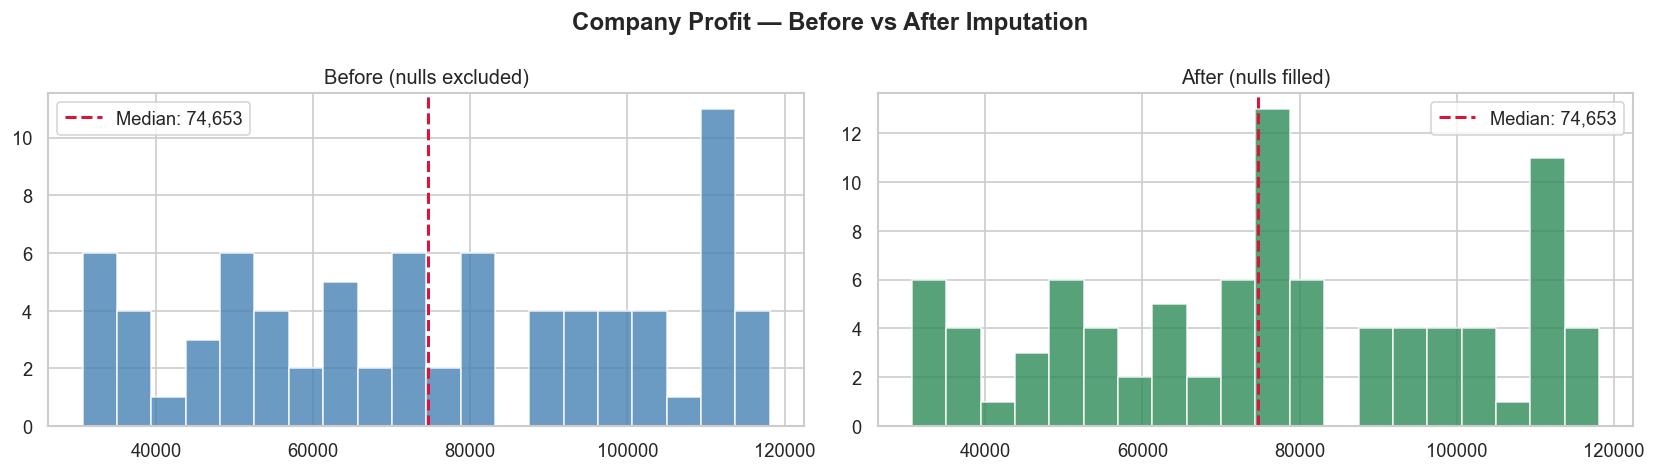

 Null values remaining: 0


In [27]:
## Customers: Impute Missing Company Profit with Median

n_null = cust["Company_Profit"].isna().sum()
median_profit = cust["Company_Profit"].median()
print(f"Null Company_Profit values : {n_null}")
print(f"Imputation value (median)  : PHP {median_profit:,.0f}")

# Store original non-null values for comparison plot
before_vals = cust["Company_Profit"].dropna().copy()

cust["Company_Profit"] = cust["Company_Profit"].fillna(median_profit)

# Visual before / after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Company Profit — Before vs After Imputation", fontweight="bold")

axes[0].hist(before_vals, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(median_profit, color="crimson", ls="--", lw=1.8, label=f"Median: {median_profit:,.0f}")
axes[0].set_title("Before (nulls excluded)")
axes[0].legend()

axes[1].hist(cust["Company_Profit"], bins=20, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(median_profit, color="crimson", ls="--", lw=1.8, label=f"Median: {median_profit:,.0f}")
axes[1].set_title("After (nulls filled)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f" Null values remaining: {cust['Company_Profit'].isna().sum()}")

In [31]:
## Products: Infer Missing Product IDs

prod = products.drop_duplicates()

n_null_pid = prod["Product_ID"].isna().sum()
print(f"Null Product_IDs: {n_null_pid}")

expected_ids = set(range(1, 21))
used_ids     = set(prod["Product_ID"].dropna().astype(int))
missing_ids  = sorted(expected_ids - used_ids)
print(f"Missing IDs inferred from sequence: {missing_ids}")

null_idx = prod[prod["Product_ID"].isna()].index
for i, idx in enumerate(null_idx):
    prod.loc[idx, "Product_ID"] = missing_ids[i]

prod["Product_ID"] = prod["Product_ID"].astype(int)

print("Products after ID fix:")
display(prod[["Product_ID", "Product_Name"]].sort_values("Product_ID"))

Null Product_IDs: 2
Missing IDs inferred from sequence: [8, 16]
Products after ID fix:


,Product_ID,Product_Name
0,1,FinPredictor Suite
1,2,MarketMinder Analytics
2,3,TrendWise Forecaster
3,4,CustomerScope Insights
4,5,SalesSync Optimizer
5,6,RevenueVue Dashboard
6,7,DataBridge Integration Tool
7,8,RiskRadar Monitor
8,9,Product 9
9,10,SegmentX Targeting


In [43]:
## Products: Parse Price Strings to Numeric Float

def parse_price(val):
    return float(re.sub(r"[^\d.]", "", str(val)))

print("Before (raw strings):")
print(prod["Product_Price"].tolist())

prod["Product_Price"] = prod["Product_Price"].apply(parse_price)

print("After (numeric float):")
print(prod["Product_Price"].tolist())
print(f" New dtype: {prod['Product_Price'].dtype}")

display(prod[["Product_ID", "Product_Name", "Product_Price"]].sort_values("Product_Price", ascending=False))

Before (raw strings):
['?140,000', '?168,000', '?100,800', '?123,200', '?84,000', '?179,200', '?151,200', '?151,200', '?112,000', '?89,600', '?156,800', '?84,000', '?196,000', '?128,800', '?100,800', '?106,400', '?168,000', '?134,400', '?95,200', '?224,000']
After (numeric float):
[140000.0, 168000.0, 100800.0, 123200.0, 84000.0, 179200.0, 151200.0, 151200.0, 112000.0, 89600.0, 156800.0, 84000.0, 196000.0, 128800.0, 100800.0, 106400.0, 168000.0, 134400.0, 95200.0, 224000.0]
 New dtype: float64


,Product_ID,Product_Name,Product_Price
19,20,FinSphere Intelligence Suite,224000.0
12,13,ForecastXcelerator,196000.0
5,6,RevenueVue Dashboard,179200.0
16,17,RealTime Revenue,168000.0
1,2,MarketMinder Analytics,168000.0
10,11,OptiFlow Automation,156800.0
6,7,DataBridge Integration Tool,151200.0
7,8,RiskRadar Monitor,151200.0
0,1,FinPredictor Suite,140000.0
17,18,DashSync Analytics Hub,134400.0


In [47]:
## Transactions: Drop Redundant Unnamed: 0 Column

trans = transactions.drop_duplicates()

print(f"Columns before: {list(trans.columns)}")
print(f"Is 'Unnamed: 0' just a row index? "
      f"{(trans['Unnamed: 0'].dropna() == trans.index[:len(trans['Unnamed: 0'].dropna())]).all()}")

trans = trans.drop(columns=["Unnamed: 0"])

print(f" Columns after : {list(trans.columns)}")
print(f"Shape         : {trans.shape}")

Columns before: ['Unnamed: 0', 'Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost']
Is 'Unnamed: 0' just a row index? False
 Columns after : ['Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity', 'Transaction_Date', 'Product_Price', 'Total_Cost']
Shape         : (10000, 7)


In [51]:
## Transactions: Impute Missing IDs

for col in ["Transaction_ID", "Company_ID", "Product_ID"]:
    trans[col] = pd.to_numeric(trans[col], errors="coerce")

# Transaction_ID
null_tid = trans["Transaction_ID"].isna().sum()
max_tid  = int(trans["Transaction_ID"].max())
new_ids  = list(range(max_tid + 1, max_tid + 1 + null_tid))
trans.loc[trans["Transaction_ID"].isna(), "Transaction_ID"] = new_ids
trans["Transaction_ID"] = trans["Transaction_ID"].astype(int)
print(f"Transaction_ID: {null_tid} nulls → assigned IDs {max_tid+1} to {max_tid+null_tid}")

# Company_ID
null_coid  = trans["Company_ID"].isna().sum()
mode_coid  = int(trans["Company_ID"].mode()[0])
trans["Company_ID"] = trans["Company_ID"].fillna(mode_coid).astype(int)
print(f"Company_ID    : {null_coid} nulls → filled with mode={mode_coid}")

# Product_ID
null_poid  = trans["Product_ID"].isna().sum()
mode_poid  = int(trans["Product_ID"].mode()[0])
trans["Product_ID"] = trans["Product_ID"].fillna(mode_poid).astype(int)
print(f"Product_ID    : {null_poid} nulls → filled with mode={mode_poid}")

print(f" Null counts after fix:")
print(trans[["Transaction_ID","Company_ID","Product_ID"]].isnull().sum())

Transaction_ID: 1000 nulls → assigned IDs 10000 to 10999
Company_ID    : 1000 nulls → filled with mode=67
Product_ID    : 1000 nulls → filled with mode=6
 Null counts after fix:
Transaction_ID    0
Company_ID        0
Product_ID        0
dtype: int64


In [57]:
## Transactions: Standardise Mixed Date Formats

def parse_date(val):
    for fmt in ("%Y/%m/%d", "%m/%d/%Y", "%m-%d-%Y",
                "%B %d, %Y", "%b %d, %Y", "%d-%m-%Y"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            pass
    return pd.NaT

print("Parsing Transaction_Date …")
trans["Transaction_Date"] = trans["Transaction_Date"].apply(parse_date)

n_nat = trans["Transaction_Date"].isna().sum()
print(f"Unparseable rows (NaT) after custom parser: {n_nat}")

# Drop the few rows that remain unparseable
trans = trans.dropna(subset=["Transaction_Date"])

print(f" Date range  : {trans['Transaction_Date'].min().date()} → {trans['Transaction_Date'].max().date()}")
print(f"dtype       : {trans['Transaction_Date'].dtype}")
print(f"Shape after : {trans.shape}")

# Confirm no mixed-type strings remain
print(f" Sample parsed dates:")
display(trans["Transaction_Date"].sample(6, random_state=1).reset_index(drop=True))

Parsing Transaction_Date …
Unparseable rows (NaT) after custom parser: 0
 Date range  : 2020-01-11 → 2024-12-10
dtype       : datetime64[ns]
Shape after : (10000, 7)
 Sample parsed dates:


0   2022-04-25
1   2022-11-19
2   2022-03-04
3   2024-05-25
4   2023-03-31
5   2022-11-16
Name: Transaction_Date, dtype: datetime64[ns]

Quantity nulls before : 1000
Quantity nulls after  : 0
Global median used as fallback: 11.0


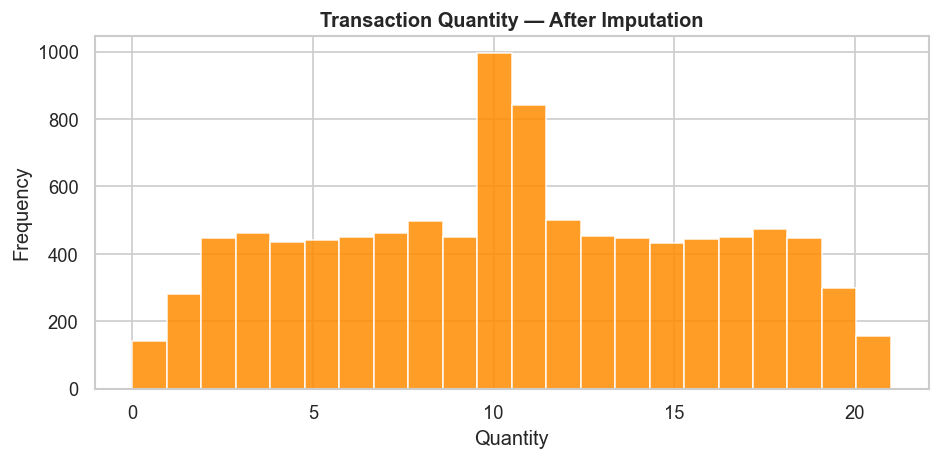

In [59]:
## Transactions: Impute Missing Quantity

trans["Quantity"] = pd.to_numeric(trans["Quantity"], errors="coerce")

null_qty_before = trans["Quantity"].isna().sum()
global_median_qty = trans["Quantity"].median()

# Per-product median imputation
trans["Quantity"] = (trans.groupby("Product_ID")["Quantity"]
                          .transform(lambda x: x.fillna(x.median())))

# Fallback: global median for any remaining nulls
trans["Quantity"] = trans["Quantity"].fillna(global_median_qty).astype(int)

null_qty_after = trans["Quantity"].isna().sum()
print(f"Quantity nulls before : {null_qty_before}")
print(f"Quantity nulls after  : {null_qty_after}")
print(f"Global median used as fallback: {global_median_qty}")

# Distribution after imputation
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(trans["Quantity"], bins=22, color="darkorange", edgecolor="white", alpha=0.85)
ax.set_title("Transaction Quantity — After Imputation", fontweight="bold")
ax.set_xlabel("Quantity")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [61]:
## Transactions: Impute Missing Product Price from Catalogue

price_map = prod.set_index("Product_ID")["Product_Price"].to_dict()
print("Price catalogue (Product_ID → Price):")
for pid, price in sorted(price_map.items()):
    print(f"  Product {pid:>2}: PHP {price:>10,.0f}")

null_pp_before = trans["Product_Price"].isna().sum()

# Apply catalogue lookup
trans["Product_Price"] = trans.apply(
    lambda r: price_map.get(int(r["Product_ID"]), np.nan)
              if pd.isna(r["Product_Price"]) else r["Product_Price"],
    axis=1
)

trans["Product_Price"] = trans["Product_Price"].fillna(trans["Product_Price"].median())

null_pp_after = trans["Product_Price"].isna().sum()
print(f" Product_Price nulls before : {null_pp_before}")
print(f"Product_Price nulls after  : {null_pp_after}")

Price catalogue (Product_ID → Price):
  Product  1: PHP    140,000
  Product  2: PHP    168,000
  Product  3: PHP    100,800
  Product  4: PHP    123,200
  Product  5: PHP     84,000
  Product  6: PHP    179,200
  Product  7: PHP    151,200
  Product  8: PHP    151,200
  Product  9: PHP    112,000
  Product 10: PHP     89,600
  Product 11: PHP    156,800
  Product 12: PHP     84,000
  Product 13: PHP    196,000
  Product 14: PHP    128,800
  Product 15: PHP    100,800
  Product 16: PHP    106,400
  Product 17: PHP    168,000
  Product 18: PHP    134,400
  Product 19: PHP     95,200
  Product 20: PHP    224,000
 Product_Price nulls before : 1000
Product_Price nulls after  : 0


In [63]:
## Transactions: Recompute Missing Total Cost

null_tc_before = trans["Total_Cost"].isna().sum()
print(f"Total_Cost nulls before recomputation: {null_tc_before}")

trans["Total_Cost"] = trans.apply(
    lambda r: r["Quantity"] * r["Product_Price"]
              if pd.isna(r["Total_Cost"]) else r["Total_Cost"],
    axis=1
)

null_tc_after = trans["Total_Cost"].isna().sum()
print(f"Total_Cost nulls after  recomputation: {null_tc_after}")

# Sanity check: compare recomputed vs original on a sample
sample = trans[["Quantity", "Product_Price", "Total_Cost"]].sample(5, random_state=42)
sample["Expected_Cost"] = sample["Quantity"] * sample["Product_Price"]
sample["Match"] = sample["Total_Cost"].round(2) == sample["Expected_Cost"].round(2)
display(sample)

Total_Cost nulls before recomputation: 1000
Total_Cost nulls after  recomputation: 0


,Quantity,Product_Price,Total_Cost,Expected_Cost,Match
6252,11,96097.400362,1.057071e+06,1.057071e+06,True
4684,10,110736.267964,5.040000e+05,1.107363e+06,False
1731,10,122403.914828,7.840000e+05,1.224039e+06,False
4742,5,110477.458370,4.032000e+05,5.523873e+05,False
4521,13,100800.000000,1.209600e+06,1.310400e+06,False


IQR fences : [-1,198,400  –  3,864,000]
Outlier rows (to be winsorised): 104


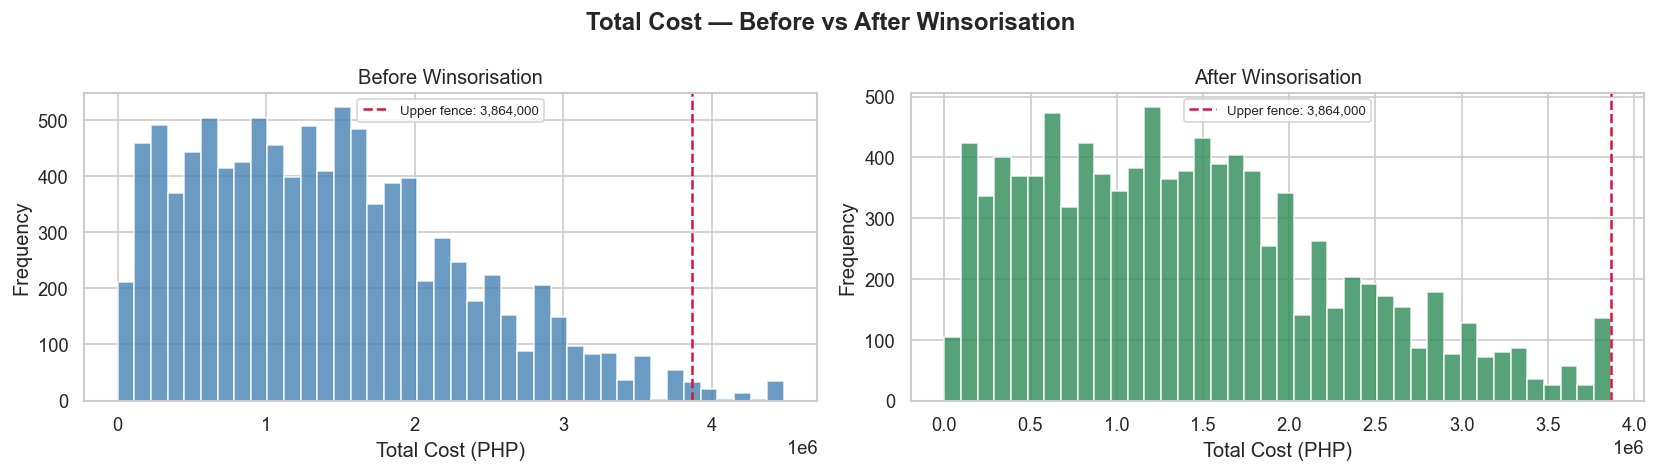

In [65]:
## Transactions: Winsorise Total Cost Outliers

q1, q3  = trans["Total_Cost"].quantile([0.25, 0.75])
iqr_val = q3 - q1
lo_fence = q1 - 1.5 * iqr_val
hi_fence = q3 + 1.5 * iqr_val

n_outliers = ((trans["Total_Cost"] < lo_fence) | (trans["Total_Cost"] > hi_fence)).sum()
print(f"IQR fences : [{lo_fence:,.0f}  –  {hi_fence:,.0f}]")
print(f"Outlier rows (to be winsorised): {n_outliers}")

before_vals = trans["Total_Cost"].copy()
trans["Total_Cost"] = trans["Total_Cost"].clip(lo_fence, hi_fence)

# Before / after plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Total Cost — Before vs After Winsorisation", fontweight="bold")

axes[0].hist(before_vals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(hi_fence, color="crimson", ls="--", lw=1.5, label=f"Upper fence: {hi_fence:,.0f}")
axes[0].set_title("Before Winsorisation")
axes[0].legend(fontsize=8)

axes[1].hist(trans["Total_Cost"], bins=40, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(hi_fence, color="crimson", ls="--", lw=1.5, label=f"Upper fence: {hi_fence:,.0f}")
axes[1].set_title("After Winsorisation")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Total Cost (PHP)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [67]:
## Final Null Check & Data Type Validation

print("═" * 55)
print("  FINAL NULL CHECK")
print("═" * 55)
for name, df in [("customers_clean", cust),
                 ("products_clean",  prod),
                 ("transactions_clean", trans)]:
    total_null = df.isnull().sum().sum()
    status     = "✓ PASS" if total_null == 0 else f"✗ FAIL — {total_null} nulls remain"
    print(f"  {name:<25}: {status}")
    if total_null > 0:
        display(df.isnull().sum()[df.isnull().sum() > 0])

print()
print("═" * 55)
print("  DATA TYPE VALIDATION")
print("═" * 55)

print(" ── customers_clean ──")
display(cust.dtypes.to_frame("dtype"))

print(" ── products_clean ──")
display(prod.dtypes.to_frame("dtype"))

print(" ── transactions_clean ──")
display(trans.dtypes.to_frame("dtype"))

print()
print("═" * 55)
print("  SHAPE SUMMARY")
print("═" * 55)
print(f"  customers_clean    : {cust.shape}")
print(f"  products_clean     : {prod.shape}")
print(f"  transactions_clean : {trans.shape}")

═══════════════════════════════════════════════════════
  FINAL NULL CHECK
═══════════════════════════════════════════════════════
  customers_clean          : ✓ PASS
  products_clean           : ✓ PASS
  transactions_clean       : ✓ PASS

═══════════════════════════════════════════════════════
  DATA TYPE VALIDATION
═══════════════════════════════════════════════════════
 ── customers_clean ──


,dtype
Company_ID,int64
Company_Name,object
Company_Profit,float64
Address,object


 ── products_clean ──


,dtype
Product_ID,int64
Product_Name,object
Product_Price,float64


 ── transactions_clean ──


,dtype
Transaction_ID,int64
Company_ID,int64
Product_ID,int64
Quantity,int64
Transaction_Date,datetime64[ns]
Product_Price,float64
Total_Cost,float64



═══════════════════════════════════════════════════════
  SHAPE SUMMARY
═══════════════════════════════════════════════════════
  customers_clean    : (90, 4)
  products_clean     : (20, 3)
  transactions_clean : (10000, 7)


In [69]:
## Save Cleaned Datasets

OUTPUT_DIR = "/Users/jemwagas/Week-2-Homework"
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_paths = {
    "customers_clean.csv"    : cust,
    "products_clean.csv"     : prod,
    "transactions_clean.csv" : trans,
}

for filename, df in out_paths.items():
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✓ {filename:<30} ({df.shape[0]:,} rows × {df.shape[1]} cols  |  {size_kb:.1f} KB)")

  ✓ customers_clean.csv            (90 rows × 4 cols  |  7.1 KB)
  ✓ products_clean.csv             (20 rows × 3 cols  |  0.7 KB)
  ✓ transactions_clean.csv         (10,000 rows × 7 cols  |  507.1 KB)
